In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("poblacion-por-alcaldia-cdmx.csv")
df

,Año,Alcaldia,Población total
0,1990,Álvaro Obregón,"640,749"
1,1990,Azcapotzalco,"474,688"
2,1990,Benito Juárez,"407,811"
3,1990,Coyoacán,"640,066"
4,1990,Cuajimalpa de Morelos,"114,385"
...,...,...,...
114,2020,Tláhuac,"392,313"
115,2020,Tlalpan,"699,928"
116,2020,Venustiano Carranza,"443,704"
117,2020,Xochimilco,"442,178"


In [3]:
# ----- Conocer el tamaño del Data Frame -----
print(f"El Data Frame tiene {df.shape[0]} filas")
print(f"El Data Frame tiene {df.shape[1]} columnas")

El Data Frame tiene 119 filas
El Data Frame tiene 3 columnas


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Año              119 non-null    int64 
 1   Alcaldia         119 non-null    object
 2   Población total  119 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.9+ KB


In [5]:
# Ver todas las alcaldías de la CDMX (están todas)
lista_de_alcaldias = list(df["Alcaldia"].unique())
numero_de_alcaldias = len(df["Alcaldia"].value_counts()) # Son 16 alcaldías pero hay una llamada "CDMX", por lo que sube a 17 alcadías
lista_de_alcaldias

['Álvaro Obregón',
 'Azcapotzalco',
 'Benito Juárez',
 'Coyoacán',
 'Cuajimalpa de Morelos',
 'Cuauhtémoc',
 'Gustavo A. Madero',
 'Iztacalco',
 'Iztapalapa',
 'La Magdalena Contreras',
 'Miguel Hidalgo',
 'Milpa Alta',
 'Tláhuac',
 'Tlalpan',
 'Venustiano Carranza',
 'Xochimilco',
 'CDMX']

In [6]:
# Ver los años que tiene el Data Frame
df["Año"].unique() # Los años del Data Frame van de 5 años en 5 años. Es decir cada lustro se hacia la medición de la población.

array([1990, 1995, 2000, 2005, 2010, 2015, 2020])

In [7]:
# Quitamos de la columna "Alcaldia" a "CDMX" para que la suma se la población sea exacta
df_solo_alcaldias = df[df["Alcaldia"] != "CDMX"]

# Vemos la cantidad de alcaldías que son ahora, ya que quitamos "CDMX"
len(df_solo_alcaldias["Alcaldia"].value_counts()) # Está bien el número (16)

# Convertimos la columna "Población total" a int (ya que está en str)
df_solo_alcaldias["Población total"] = (df_solo_alcaldias["Población total"].str.replace(",", "", regex=False).astype(int)) # Quitamos las comas y convertimos a int

/var/folders/8k/r7mpdwj10lq28v41d5cp4mjr0000gn/T/ipykernel_1607/958835878.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_solo_alcaldias["Población total"] = (df_solo_alcaldias["Población total"].str.replace(",", "", regex=False).astype(int)) # Quitamos las comas y convertimos a int


In [8]:
# ----- Cantidad total de la población en el último año (para ver la suma total) -----

# Filtramos el Data Frame por el año 2020
poblacion_2020 = df_solo_alcaldias[df_solo_alcaldias["Año"] == 2020]

# Agrupamos la población del 2020 por alcaldía
poblacion_2020.groupby("Alcaldia")["Población total"].sum()
total_poblacion_cdmx = poblacion_2020["Población total"].sum()

# Mostramos en pantalla
print(f"La cantidad total de personas que hay en la CDMX es de {total_poblacion_cdmx:,.2f}") # 9,209,944 personas

La cantidad total de personas que hay en la CDMX es de 9,209,944.00


/var/folders/8k/r7mpdwj10lq28v41d5cp4mjr0000gn/T/ipykernel_1607/1645119267.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(x=poblacion_total_por_alcaldia.index,


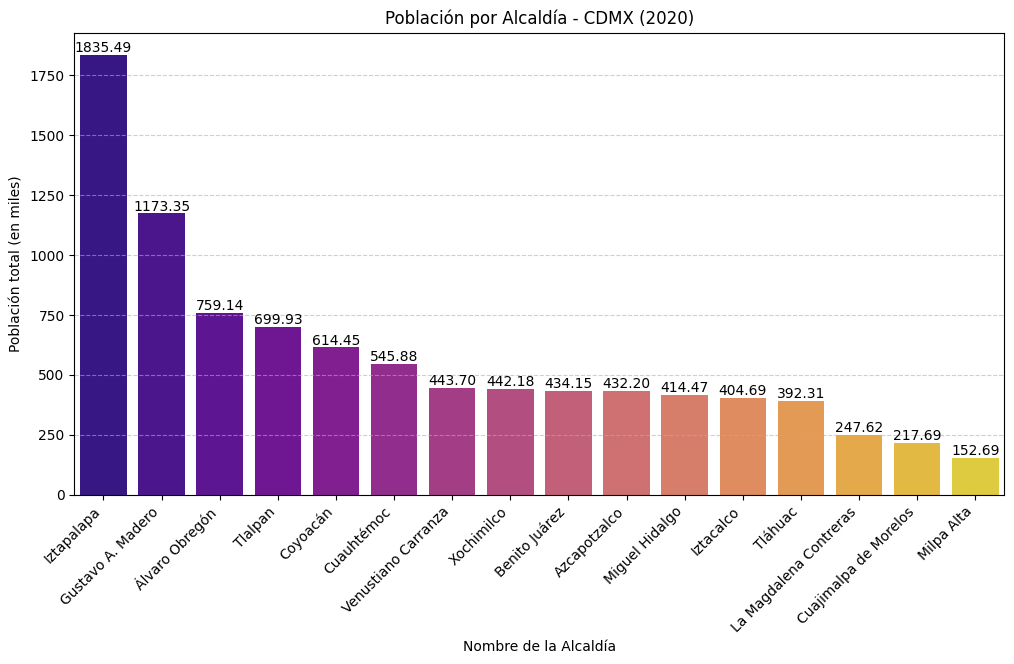

In [9]:
# ----- Graficamos la población por alcaldía -----
poblacion_total_por_alcaldia = poblacion_2020.groupby("Alcaldia")["Población total"].sum().sort_values(ascending=False)
# Graficamos
plt.figure(figsize=(12,6))
plt.title("Población por Alcaldía - CDMX (2020)")
barras = sns.barplot(x=poblacion_total_por_alcaldia.index,
                     y=poblacion_total_por_alcaldia.values / 1000,
                     palette="plasma")
# Agregamos el número de habitantes en cada barra
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='%.2f')
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.xlabel("Nombre de la Alcaldía")
plt.ylabel("Población total (en miles)")
plt.xticks(rotation=45,
           ha="right")
plt.show()

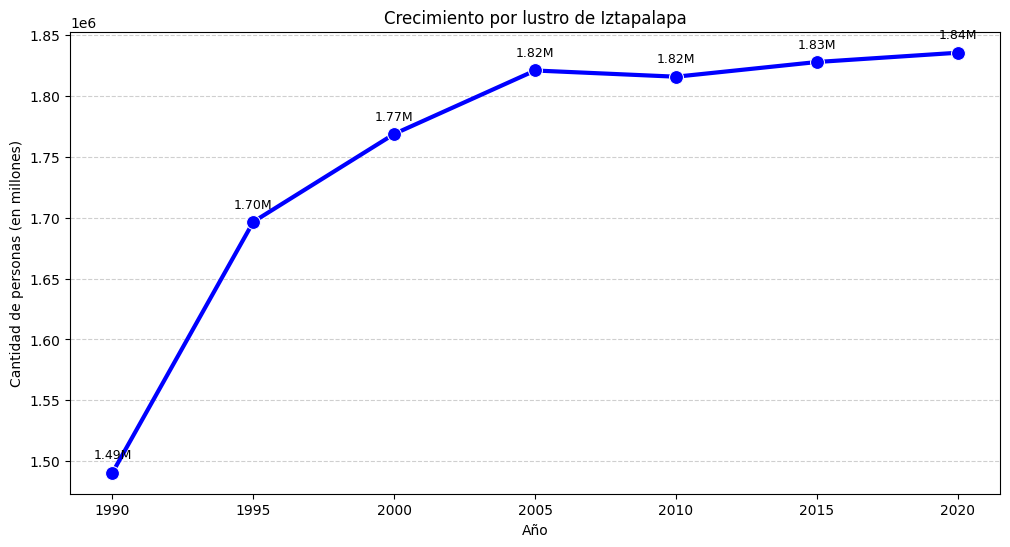

In [30]:
# ----- Grafica del crecimiento por lustro de Iztapalapa -----

# Creamos un Data Frame solo de Iztapalapa
df_iztapalapa = df_solo_alcaldias[df_solo_alcaldias["Alcaldia"] == "Iztapalapa"]

# Agrupamos a Iztapalapa por año y población total
crecimiento_iztapalapa = df_iztapalapa.groupby("Año")["Población total"].sum()

# Graficamos
plt.figure(figsize=(12,6))
plt.title("Crecimiento por lustro de Iztapalapa")
sns.lineplot(x=crecimiento_iztapalapa.index,
             y=crecimiento_iztapalapa.values,
             color="blue",
             marker="o",
             linewidth=3,
             markersize=10)

# Después de tu sns.lineplot, añade:
for i, (year, pop) in enumerate(zip(crecimiento_iztapalapa.index, crecimiento_iztapalapa.values)):
    plt.annotate(f'{pop/1e6:.2f}M', 
                 (year, pop), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center',
                 fontsize=9)

plt.xlabel("Año")
plt.ylabel("Cantidad de personas (en millones)")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()
